In [1]:
import os
import sys
import sqlite3
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler

# 1. Dynamically locate your data warehouse ROOT directory
notebook_path = Path(os.getcwd())
root_dir = notebook_path
while root_dir.name != "data_warehouse" and root_dir.parent != root_dir:
    root_dir = root_dir.parent

# Fallback path if the root folder name isn't exactly 'data_warehouse'
if root_dir.name != "data_warehouse":
    root_dir = notebook_path.parent

# 2. Add the ROOT path to Python's system path for imports
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

# 3. Explicitly define your database locations
db_dir = root_dir / "databases"
sba_db_path = db_dir / "sba_7a_analysis.db"
spatial_db_path = db_dir / "spatial_crosswalk.db"

# 4. Initialize the custom GeographyDaemon using our verified db directory
from utils.geography_daemon import GeographyDaemon
daemon = GeographyDaemon(database_dir=db_dir)

print("=========================================================")
print("✅ CELL 1: ENVIRONMENT SETUP & DAEMON PROVISIONED")
print("=========================================================")
print(f"Data Warehouse ROOT: {root_dir}")
print(f"SBA Database Path:   {sba_db_path.exists()}")
print(f"Spatial DB Path:     {spatial_db_path.exists()}")
print("GeographyDaemon:      Initialized and ready.")


✅ CELL 1: ENVIRONMENT SETUP & DAEMON PROVISIONED
Data Warehouse ROOT: /Users/bonwier/PythonProjects/data_warehouse
SBA Database Path:   True
Spatial DB Path:     True
GeographyDaemon:      Initialized and ready.


In [2]:
# 1. Define your 13 broad 4-digit NAICS categories for the Peri-Urban pool
ag_naics_map = {
    '3118': 'Processing: Artisanal Bakeries',
    '3119': 'Processing: Specialty Foods',
    '3116': 'Processing: Meat & Slaughtering',
    '3114': 'Processing: Fruit/Veg Preserving',
    '3115': 'Processing: Dairy Manufacturing',
    '1114': 'Production: Controlled-Env Ag (CEA)',
    '1119': 'Production: Diversified Market Gardens',
    '1112': 'Production: Vegetable & Melon Farming',
    '1113': 'Production: Fruit & Tree Nut Farming',
    '4244': 'Pipelines: Food Hub Wholesalers',
    '1151': 'Pipelines: Crop Production Support',
    '1152': 'Pipelines: Animal Support/Veterinary',
    '1121': 'Pipelines: Boutique Livestock/Grazing'
}

# 2. Programmatically convert the keys into a clean string tuple for SQL filtering
sql_naics_tuple = tuple(ag_naics_map.keys())

print("=========================================================")
print("✅ CELL 2: AG PORTFOLIO METADATA MAP GENERATED")
print("=========================================================")
print(f"Total Industry Baskets Defined: {len(ag_naics_map)}")
print(f"SQL Formatted Tuple Key:        {sql_naics_tuple}")


✅ CELL 2: AG PORTFOLIO METADATA MAP GENERATED
Total Industry Baskets Defined: 13
SQL Formatted Tuple Key:        ('3118', '3119', '3116', '3114', '3115', '1114', '1119', '1112', '1113', '4244', '1151', '1152', '1121')


In [3]:

# 1. Connect to the master SBA analytical database
sba_conn = sqlite3.connect(sba_db_path)

# 2. Build the optimized query using our formatted SQL tuple
query_all_ag = f"""
SELECT 
    asofdate,
    locationid, 
    approvaldate, 
    paidinfulldate, 
    chargeoffdate, 
    isdefaulted, 
    terminmonths, 
    grossapproval, 
    naicscode, 
    projectstate
FROM model_cohort_2003_present
WHERE SUBSTR(CAST(naicscode AS TEXT), 1, 4) IN {sql_naics_tuple};
"""

# 3. Read the data directly into a primary pandas DataFrame
df_raw_ag = pd.read_sql_query(query_all_ag, sba_conn)
sba_conn.close()

print("=========================================================")
print("✅ CELL 3: REGIONAL AG DATA FOOTPRINT EXTRACTED")
print("=========================================================")
print(f"Total Target Loans Extracted: {len(df_raw_ag)}")
print("DataFrame columns loaded:")
print(list(df_raw_ag.columns))


✅ CELL 3: REGIONAL AG DATA FOOTPRINT EXTRACTED
Total Target Loans Extracted: 26293
DataFrame columns loaded:
['asofdate', 'locationid', 'approvaldate', 'paidinfulldate', 'chargeoffdate', 'isdefaulted', 'terminmonths', 'grossapproval', 'naicscode', 'projectstate']


In [4]:

# 1. Convert text timestamps into proper datetime objects
df_raw_ag['as_of_dt'] = pd.to_datetime(df_raw_ag['asofdate'], errors='coerce')
df_raw_ag['approval_dt'] = pd.to_datetime(df_raw_ag['approvaldate'], errors='coerce')
df_raw_ag['paid_dt'] = pd.to_datetime(df_raw_ag['paidinfulldate'], errors='coerce')
df_raw_ag['chg_dt'] = pd.to_datetime(df_raw_ag['chargeoffdate'], errors='coerce')

# 2. Drop rows that lack an approval date to safeguard timeline anchor points
df_raw_ag = df_raw_ag.dropna(subset=['approval_dt']).copy()

# 3. Extract the integer calendar year of origination
df_raw_ag['start_year'] = df_raw_ag['approval_dt'].dt.year.astype(int)

print("=========================================================")
print("✅ CELL 4: TIMELINE STRATEGIES STANDARD-PARSED")
print("=========================================================")
print(f"Loans remaining after missing-date cleanup: {len(df_raw_ag)}")
print("Sample of processed date columns:")
print(df_raw_ag[['approval_dt', 'paid_dt', 'chg_dt', 'start_year', 'as_of_dt']].head(3))


✅ CELL 4: TIMELINE STRATEGIES STANDARD-PARSED
Loans remaining after missing-date cleanup: 26293
Sample of processed date columns:
  approval_dt    paid_dt     chg_dt  start_year   as_of_dt
0  2004-12-27        NaT 2011-05-06        2004 2026-03-31
1  2015-01-23 2025-01-31        NaT        2015 2026-03-31
2  2014-06-17 2021-06-30        NaT        2014 2026-03-31


In [5]:


# 1. Dynamically Establish the true historical snapshot cutoff date. (this should by definition be the same date for every record in the database)
snapshot_dt = df_raw_ag['as_of_dt'].max()


# 2. Vectorized calculation of active days under all three potential endpoints
days_to_chg = (df_raw_ag['chg_dt'] - df_raw_ag['approval_dt']).dt.days
days_to_paid = (df_raw_ag['paid_dt'] - df_raw_ag['approval_dt']).dt.days
days_to_snapshot = (snapshot_dt - df_raw_ag['approval_dt']).dt.days

# 3. Choose the correct active duration days based on chronological priority
calculated_days = np.select(
    condlist=[df_raw_ag['chg_dt'].notna(), df_raw_ag['paid_dt'].notna()],
    choicelist=[days_to_chg, days_to_paid],
    default=days_to_snapshot
)

# 4. Convert active days to fractional years, enforcing a minimum of 0.1 years to avoid zero-duration errors
df_raw_ag['duration_years'] = np.maximum(0.1, calculated_days / 365.25)

# 5. Build the binary Default Event tracker (1 = Defaulted, 0 = Paid Off / Active)
df_raw_ag['default_event'] = df_raw_ag['isdefaulted'].fillna(0).astype(int)

print("=========================================================")
print("✅ CELL 5: CORRECTED LIFETIME SURVIVAL TIMELINES CALCULATED")
print("=========================================================")
print(f"Total Portfolio Default Events Captured: {df_raw_ag['default_event'].sum()}")
print(f"Right-censored as of {snapshot_dt}")
print("\nSample of computed corrected survival timelines (T, E):")
print(df_raw_ag[['duration_years', 'default_event']].head(5))


✅ CELL 5: CORRECTED LIFETIME SURVIVAL TIMELINES CALCULATED
Total Portfolio Default Events Captured: 2872
Right-censored as of 2026-03-31 00:00:00

Sample of computed corrected survival timelines (T, E):
   duration_years  default_event
0        6.354552              1
1       10.023272              0
2        7.036277              0
3        5.223819              0
4       10.677618              0


In [6]:
# 1. Connect to the spatial database and pull the entire crosswalk matrix into memory
crosswalk_conn = sqlite3.connect(spatial_db_path)
df_cw_cache = pd.read_sql_query(
    "SELECT source_naics, target_naics FROM dim_naics_crosswalk WHERE mapping_type='NAICS_REVISION';", 
    crosswalk_conn
)
crosswalk_conn.close()

# 2. Clean whitespace and build a high-speed O(1) Python dictionary lookup map
df_cw_cache['source_naics'] = df_cw_cache['source_naics'].astype(str).str.strip()
df_cw_cache['target_naics'] = df_cw_cache['target_naics'].astype(str).str.strip()
naics_lookup_dict = dict(zip(df_cw_cache['source_naics'], df_cw_cache['target_naics']))

# 3. Define the fast dictionary-based recursive crosswalk function
def fast_crosswalk_resolver(raw_naics):
    if pd.isna(raw_naics) or str(raw_naics).strip() == "":
        return None
    # Intercept and clean float representations (e.g., 3116.0 -> '3116')
    naics_str = str(raw_naics).strip().split('.')[0]
    
    # Trace the code forward through its census updates up to 5 times natively in Python
    for _ in range(5):
        if naics_str in naics_lookup_dict:
            naics_str = naics_lookup_dict[naics_str]
        else:
            break
    return naics_str

# 4. Execute the crosswalk and assign the 13 broad industry labels
print("Aligning historical loan records via in-memory crosswalk lookup...")
df_raw_ag['resolved_naics'] = df_raw_ag['naicscode'].apply(fast_crosswalk_resolver)
df_raw_ag['naics_4digit'] = df_raw_ag['resolved_naics'].astype(str).str.strip().str[:4]
df_raw_ag['industry_label'] = df_raw_ag['naics_4digit'].map(ag_naics_map)

print("\n=========================================================")
print("✅ CELL 6: IN-MEMORY CROSSWALK RE-ALIGNMENT COMPLETE")
print("=========================================================")
print(f"Total rows successfully run through the crosswalk: {len(df_raw_ag)}")
print(f"Total rows that successfully matched your 13 ag buckets: {df_raw_ag['industry_label'].notna().sum()}")


Aligning historical loan records via in-memory crosswalk lookup...

✅ CELL 6: IN-MEMORY CROSSWALK RE-ALIGNMENT COMPLETE
Total rows successfully run through the crosswalk: 26293
Total rows that successfully matched your 13 ag buckets: 26293


In [7]:
# 1. Define the programmatic mapping to collapse 13 categories into 3 Macro-Sectors
def assign_macro_sector(naics):
    if naics in ['3114', '3115', '3116', '3118', '3119']:
        return 'Processing_Complex'
    elif naics in ['1112', '1113', '1114', '1119']:
        return 'Production_Cluster'
    elif naics in ['1121', '1151', '1152', '4244']:
        return 'Pipeline_Support'
    return None

df_raw_ag['macro_sector'] = df_raw_ag['naics_4digit'].apply(assign_macro_sector)

# 2. Isolate Capital Structure Stratification (1 = Short-Term Line, 0 = Long-Term Debt)
df_raw_ag['is_short_term'] = (df_raw_ag['terminmonths'] <= 36).astype(int)

# 3. Combine them into the definitive 6-tier composite key
df_raw_ag['macro_strata_key'] = df_raw_ag['macro_sector'] + "_" + df_raw_ag['is_short_term'].astype(str)

# 4. Filter for rows that have valid mappings (safeguard)
df_portfolio = df_raw_ag.dropna(subset=['macro_sector']).copy()

print("=========================================================")
print("✅ CELL 7: HARDENED MACRO-SECTORS COMPILED")
print("=========================================================")
print(f"Total loan rows successfully structured: {len(df_portfolio)}")
print(f"Total unique pricing staircases created (Target: 6): {df_portfolio['macro_strata_key'].nunique()}")
print("\nBreakdown of loans per pricing staircase:")
print(df_portfolio['macro_strata_key'].value_counts())



✅ CELL 7: HARDENED MACRO-SECTORS COMPILED
Total loan rows successfully structured: 26293
Total unique pricing staircases created (Target: 6): 6

Breakdown of loans per pricing staircase:
macro_strata_key
Processing_Complex_0    11298
Pipeline_Support_0      10706
Production_Cluster_0     1764
Pipeline_Support_1       1514
Processing_Complex_1      847
Production_Cluster_1      164
Name: count, dtype: int64


Plotting the true 13 baseline cumulative hazard curves...


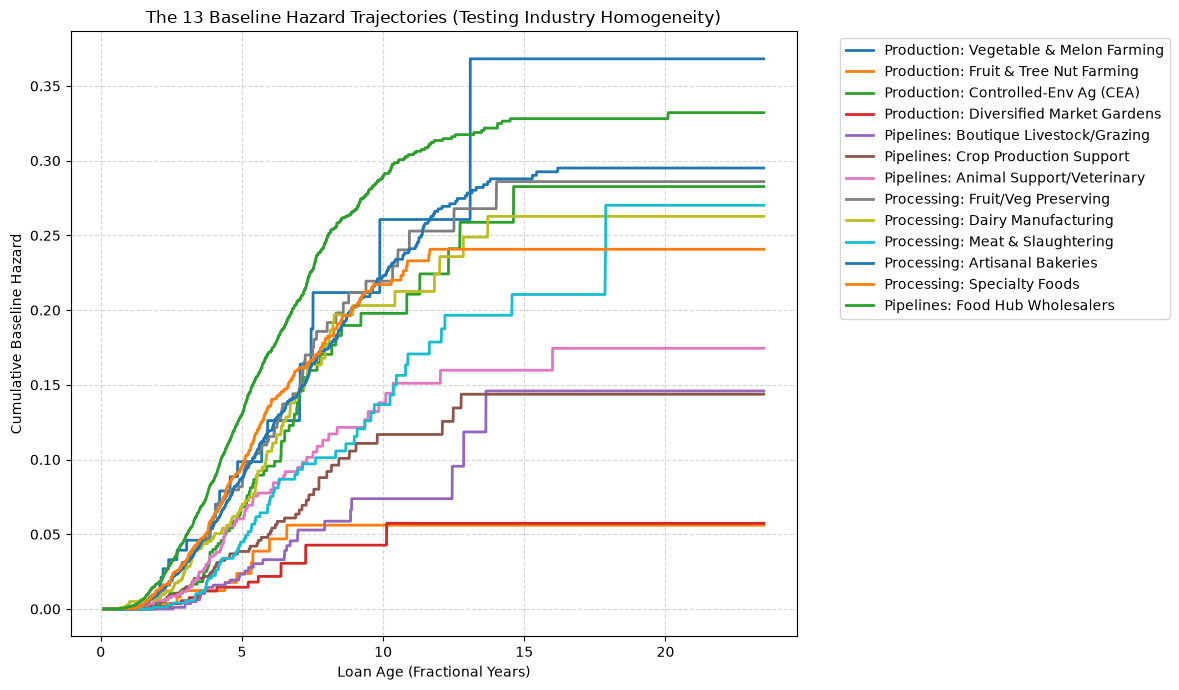

In [8]:
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt

# 1. Create a clean subset of your data with your continuous variable scaled
df_diagnostic = df_portfolio[['duration_years', 'default_event', 'grossapproval', 'naics_4digit', 'industry_label']].copy()
scaler_diag = StandardScaler()
df_diagnostic[['grossapproval']] = scaler_diag.fit_transform(df_diagnostic[['grossapproval']])

# 2. Fit a Cox model stratified strictly across all 13 4-digit NAICS codes
cph_diagnostic = CoxPHFitter()
cph_diagnostic.fit(
    df_diagnostic[['duration_years', 'default_event', 'grossapproval', 'naics_4digit']],
    duration_col='duration_years',
    event_col='default_event',
    strata=['naics_4digit']
)

# 3. Extract and plot the 13 baseline hazard curves to visually inspect overlap
print("Plotting the true 13 baseline cumulative hazard curves...")
plt.figure(figsize=(12, 7))
for col in cph_diagnostic.baseline_cumulative_hazard_.columns:
    # Look up the readable name from your metadata map
    label_text = ag_naics_map.get(col, col)
    plt.plot(cph_diagnostic.baseline_cumulative_hazard_[col], label=label_text, lw=2)

plt.title("The 13 Baseline Hazard Trajectories (Testing Industry Homogeneity)")
plt.xlabel("Loan Age (Fractional Years)")
plt.ylabel("Cumulative Baseline Hazard")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [9]:
from lifelines import CoxPHFitter
import scipy.stats as stats

# 1. Prepare a clean matrix copy for the conditional verification test
df_interaction = df_portfolio[['duration_years', 'default_event', 'grossapproval', 'is_short_term', 'macro_sector']].copy()
scaler_int = StandardScaler()
df_interaction[['grossapproval']] = scaler_int.fit_transform(df_interaction[['grossapproval']])

# 2. Fit Model 1: Stratified ONLY by capital structure duration (2 strata)
print("Fitting Model 1: Duration-Only Stratification Baseline...")
cph_model_1 = CoxPHFitter()
cph_model_1.fit(
    df_interaction[['duration_years', 'default_event', 'grossapproval', 'is_short_term']],
    duration_col='duration_years',
    event_col='default_event',
    strata=['is_short_term']
)
log_lik_1 = cph_model_1.log_likelihood_

# 3. Fit Model 2: Two-Way Interaction Stratification (6 strata: 3 industries x 2 durations)
print("Fitting Model 2: Two-Way Capital & Industry Stratification...")
cph_model_2 = CoxPHFitter()
cph_model_2.fit(
    df_interaction[['duration_years', 'default_event', 'grossapproval', 'macro_sector', 'is_short_term']],
    duration_col='duration_years',
    event_col='default_event',
    strata=['macro_sector', 'is_short_term']
)
log_lik_2 = cph_model_2.log_likelihood_

# 4. Compute the Likelihood Ratio Test Statistic to render the verdict
lrt_interaction_stat = 2 * (log_lik_2 - log_lik_1)
# The degrees of freedom difference is 4 (moving from 2 strata to 6 strata)
p_val_interaction = 1 - stats.chi2.cdf(lrt_interaction_stat, df=4)

print("\n=========================================================")
print("          TWO-WAY INTERACTION HYPOTHESIS VERDICT         ")
print("=========================================================")
print(f"Model 1 (Duration Only) Log-Likelihood: {round(log_lik_1, 2)}")
print(f"Model 2 (Combined Two-Way) Log-Likelihood: {round(log_lik_2, 2)}")
print(f"Likelihood Ratio Chi-Squared Statistic: {round(lrt_interaction_stat, 2)}")
print(f"Chi-Squared p-value for Industry Layer: {p_val_interaction}")
print("=========================================================")


Fitting Model 1: Duration-Only Stratification Baseline...
Fitting Model 2: Two-Way Capital & Industry Stratification...

          TWO-WAY INTERACTION HYPOTHESIS VERDICT         
Model 1 (Duration Only) Log-Likelihood: -24000.93
Model 2 (Combined Two-Way) Log-Likelihood: -21583.19
Likelihood Ratio Chi-Squared Statistic: 4835.49
Chi-Squared p-value for Industry Layer: 0.0
